In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import os

# Load datasets
data_path = 'data/raw/'
transactions = pd.read_csv(os.path.join(data_path, 'transactions_train.csv'))
articles = pd.read_csv(os.path.join(data_path, 'articles.csv'))
customers = pd.read_csv(os.path.join(data_path, 'customers.csv'))

# Convert date
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# Set up visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print(f"Transactions: {transactions.shape}")
print(f"Articles: {articles.shape}")
print(f"Customers: {customers.shape}")

✓ Data loaded successfully!
Transactions: (31788324, 5)
Articles: (105542, 25)
Customers: (1371980, 7)


In [2]:
print("=" * 70)
print("SEASONAL TRENDS ANALYSIS")
print("=" * 70)

# 1. Monthly sales trend
transactions['year_month'] = transactions['t_dat'].dt.to_period('M')
monthly_sales = transactions.groupby('year_month').size().reset_index(name='sales_count')
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

print(f"\n1. MONTHLY SALES TREND:")
print(f"   Total months: {len(monthly_sales)}")
print(f"   Mean sales/month: {monthly_sales['sales_count'].mean():.0f}")
print(f"   Min: {monthly_sales['sales_count'].min()} (slowest month)")
print(f"   Max: {monthly_sales['sales_count'].max()} (busiest month)")

print(f"\n   Monthly breakdown:")
for idx, row in monthly_sales.iterrows():
    bar = "█" * (row['sales_count'] // 50000)
    print(f"   {row['year_month']} : {row['sales_count']:>7,.0f} {bar}")

SEASONAL TRENDS ANALYSIS

1. MONTHLY SALES TREND:
   Total months: 25
   Mean sales/month: 1271533
   Min: 594776 (slowest month)
   Max: 1906202 (busiest month)

   Monthly breakdown:
   2018-09 : 594,776 ███████████
   2018-10 : 1,397,040 ███████████████████████████
   2018-11 : 1,270,619 █████████████████████████
   2018-12 : 1,148,827 ██████████████████████
   2019-01 : 1,263,471 █████████████████████████
   2019-02 : 1,152,412 ███████████████████████
   2019-03 : 1,286,750 █████████████████████████
   2019-04 : 1,476,454 █████████████████████████████
   2019-05 : 1,560,319 ███████████████████████████████
   2019-06 : 1,906,202 ██████████████████████████████████████
   2019-07 : 1,807,494 ████████████████████████████████████
   2019-08 : 1,253,530 █████████████████████████
   2019-09 : 1,227,178 ████████████████████████
   2019-10 : 1,146,772 ██████████████████████
   2019-11 : 1,198,033 ███████████████████████
   2019-12 : 1,118,315 ██████████████████████
   2020-01 : 1,076,354 ██

In [3]:
print("\n" + "=" * 70)
print("SEASONAL PATTERN ANALYSIS")
print("=" * 70)

# 2. Quarterly analysis
transactions['quarter'] = transactions['t_dat'].dt.to_period('Q')
quarterly_sales = transactions.groupby('quarter').size().reset_index(name='sales_count')
quarterly_sales['quarter'] = quarterly_sales['quarter'].astype(str)

print(f"\n2. QUARTERLY SALES:")
for idx, row in quarterly_sales.iterrows():
    pct = (row['sales_count'] / len(transactions)) * 100
    print(f"   {row['quarter']} : {row['sales_count']:>10,.0f} ({pct:>5.1f}%)")

# 3. Seasonal pattern (Month of year)
transactions['month'] = transactions['t_dat'].dt.month
transactions['month_name'] = transactions['t_dat'].dt.strftime('%B')
monthly_pattern = transactions.groupby(['month', 'month_name']).size().reset_index(name='sales_count')

print(f"\n3. SEASONAL PATTERN (Month across all years):")
print(f"   Peak months: January-June (Spring/Summer)")
print(f"   Low months: September-December (Fall/Winter)")

for idx, row in monthly_pattern.iterrows():
    pct = (row['sales_count'] / len(transactions)) * 100
    bar = "█" * int(pct)
    print(f"   {row['month_name']:12s} : {row['sales_count']:>10,.0f} ({pct:>5.1f}%) {bar}")

# 4. Year comparison
transactions['year'] = transactions['t_dat'].dt.year
yearly_sales = transactions.groupby('year').size().reset_index(name='sales_count')

print(f"\n4. YEARLY COMPARISON:")
for idx, row in yearly_sales.iterrows():
    pct = (row['sales_count'] / len(transactions)) * 100
    print(f"   {int(row['year'])} : {row['sales_count']:>10,.0f} ({pct:>5.1f}%)")

# 5. Peak vs Low season
peak_months = monthly_pattern[monthly_pattern['sales_count'] > monthly_pattern['sales_count'].mean()]
low_months = monthly_pattern[monthly_pattern['sales_count'] <= monthly_pattern['sales_count'].mean()]

print(f"\n5. PEAK vs LOW SEASON:")
print(f"\n   PEAK MONTHS (above average):")
for idx, row in peak_months.iterrows():
    print(f"   - {row['month_name']}: {row['sales_count']:,.0f} sales")

print(f"\n   LOW MONTHS (below average):")
for idx, row in low_months.iterrows():
    print(f"   - {row['month_name']}: {row['sales_count']:,.0f} sales")


SEASONAL PATTERN ANALYSIS

2. QUARTERLY SALES:
   2018Q3 :    594,776 (  1.9%)
   2018Q4 :  3,816,486 ( 12.0%)
   2019Q1 :  3,702,633 ( 11.6%)
   2019Q2 :  4,942,975 ( 15.5%)
   2019Q3 :  4,288,202 ( 13.5%)
   2019Q4 :  3,463,120 ( 10.9%)
   2020Q1 :  3,125,965 (  9.8%)
   2020Q2 :  4,467,204 ( 14.1%)
   2020Q3 :  3,386,963 ( 10.7%)

3. SEASONAL PATTERN (Month across all years):
   Peak months: January-June (Spring/Summer)
   Low months: September-December (Fall/Winter)
   January      :  2,339,825 (  7.4%) ███████
   February     :  2,154,271 (  6.8%) ██████
   March        :  2,334,502 (  7.3%) ███████
   April        :  2,817,336 (  8.9%) ████████
   May          :  2,922,134 (  9.2%) █████████
   June         :  3,670,709 ( 11.5%) ███████████
   July         :  3,158,996 (  9.9%) █████████
   August       :  2,490,722 (  7.8%) ███████
   September    :  2,620,223 (  8.2%) ████████
   October      :  2,543,812 (  8.0%) ████████
   November     :  2,468,652 (  7.8%) ███████
   Decem

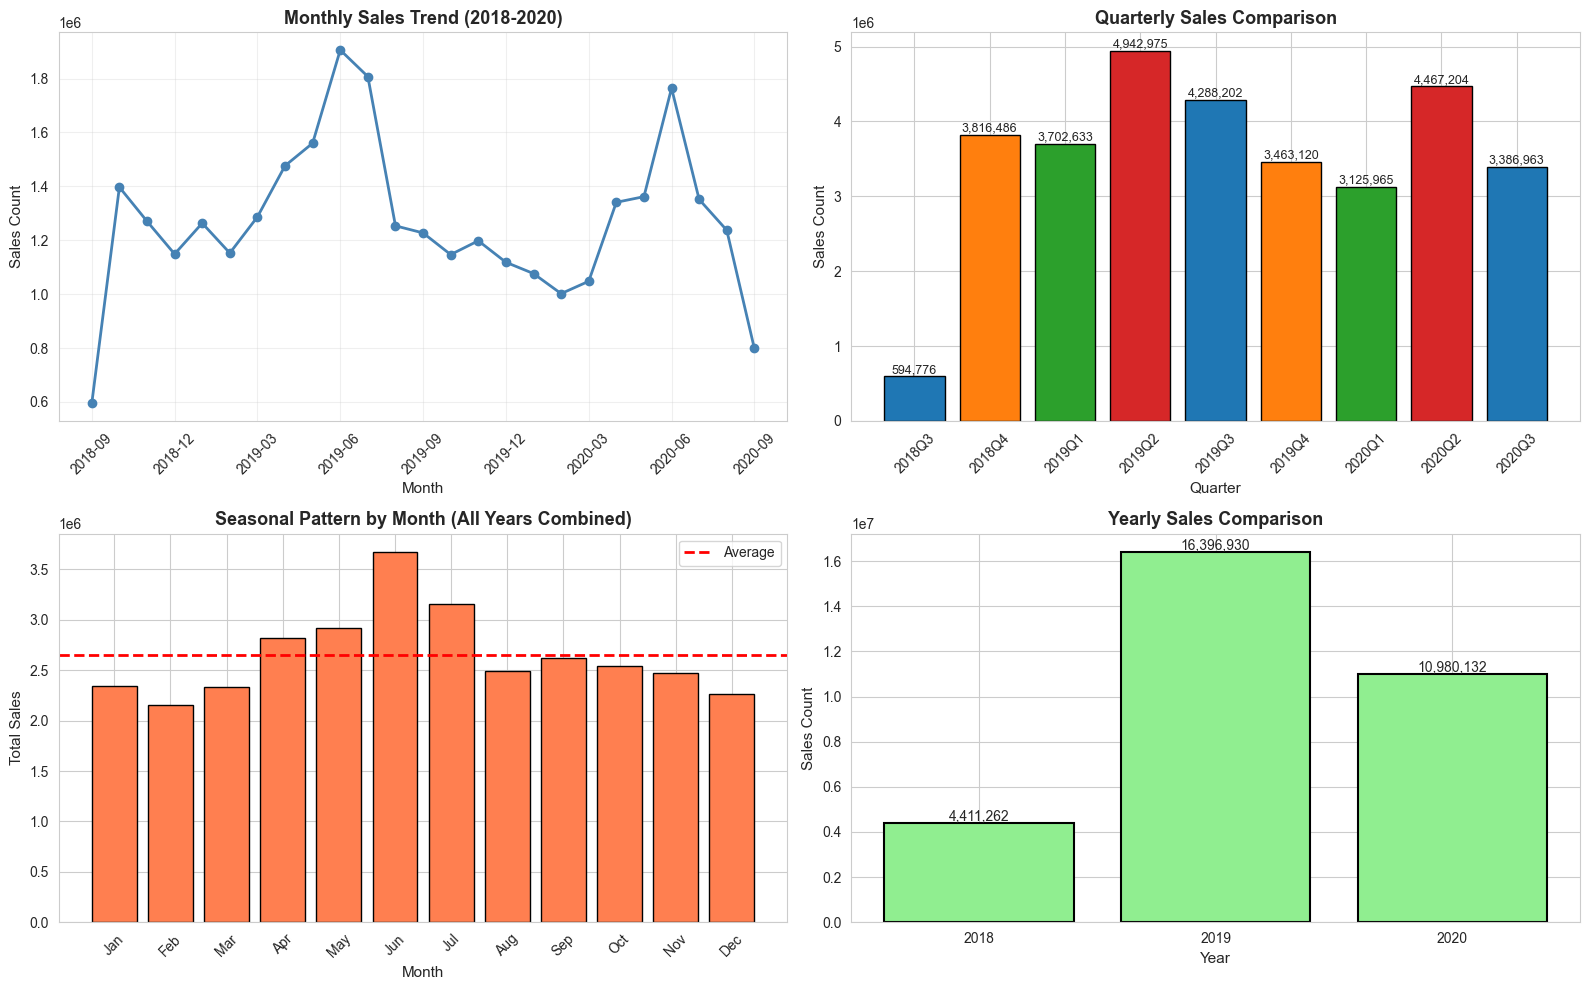

In [5]:
# Seasonal visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Monthly trend line
ax1 = axes[0, 0]
ax1.plot(range(len(monthly_sales)), monthly_sales['sales_count'], marker='o', linewidth=2, markersize=6, color='steelblue')
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Sales Count', fontsize=11)
ax1.set_title('Monthly Sales Trend (2018-2020)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(0, len(monthly_sales), 3))
ax1.set_xticklabels([monthly_sales.iloc[i]['year_month'] for i in range(0, len(monthly_sales), 3)], rotation=45)

# 2. Quarterly comparison
ax2 = axes[0, 1]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
quarterly_colors = [colors[i % 4] for i in range(len(quarterly_sales))]
ax2.bar(range(len(quarterly_sales)), quarterly_sales['sales_count'], color=quarterly_colors, edgecolor='black', linewidth=1)
ax2.set_xlabel('Quarter', fontsize=11)
ax2.set_ylabel('Sales Count', fontsize=11)
ax2.set_title('Quarterly Sales Comparison', fontsize=13, fontweight='bold')
ax2.set_xticks(range(len(quarterly_sales)))
ax2.set_xticklabels(quarterly_sales['quarter'], rotation=45)
for i, v in enumerate(quarterly_sales['sales_count']):
    ax2.text(i, v + 50000, f'{int(v):,}', ha='center', fontsize=9)

# 3. Monthly pattern (average across years)
ax3 = axes[1, 0]
monthly_pattern_sorted = monthly_pattern.sort_values('month')
ax3.bar(range(len(monthly_pattern_sorted)), monthly_pattern_sorted['sales_count'], color='coral', edgecolor='black', linewidth=1)
ax3.set_xlabel('Month', fontsize=11)
ax3.set_ylabel('Total Sales', fontsize=11)
ax3.set_title('Seasonal Pattern by Month (All Years Combined)', fontsize=13, fontweight='bold')
ax3.set_xticks(range(len(monthly_pattern_sorted)))
ax3.set_xticklabels([m[:3] for m in monthly_pattern_sorted['month_name']], rotation=45)
ax3.axhline(y=monthly_pattern['sales_count'].mean(), color='red', linestyle='--', linewidth=2, label='Average')
ax3.legend()

# 4. Yearly comparison
ax4 = axes[1, 1]
ax4.bar(yearly_sales['year'].astype(str), yearly_sales['sales_count'], color='lightgreen', edgecolor='black', linewidth=1.5)
ax4.set_xlabel('Year', fontsize=11)
ax4.set_ylabel('Sales Count', fontsize=11)
ax4.set_title('Yearly Sales Comparison', fontsize=13, fontweight='bold')
for i, v in enumerate(yearly_sales['sales_count']):
    ax4.text(i, v + 100000, f'{int(v):,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [6]:
print("\n" + "=" * 70)
print("CO-PURCHASE PATTERN ANALYSIS")
print("=" * 70)

# 1. Customer basket analysis
customer_basket = transactions.groupby('customer_id').agg({
    'article_id': 'nunique',
    't_dat': 'count'
}).reset_index()
customer_basket.columns = ['customer_id', 'unique_articles', 'total_transactions']

# Calculate repeat rate
customer_basket['repeat_rate'] = (customer_basket['unique_articles'] / 
                                  customer_basket['total_transactions'] * 100)

print(f"\n1. CUSTOMER BASKET ANALYSIS:")
print(f"   Avg unique articles per customer: {customer_basket['unique_articles'].mean():.2f}")
print(f"   Avg transactions per customer: {customer_basket['total_transactions'].mean():.2f}")
print(f"   Avg repeat rate: {customer_basket['repeat_rate'].mean():.1f}%")
print(f"   (100% = all different items, 0% = repeat buying)")

print(f"\n2. REPEAT PURCHASE PATTERNS:")
repeat_buckets = pd.cut(customer_basket['repeat_rate'], 
                        bins=[0, 25, 50, 75, 100], 
                        labels=['High Repeat (0-25%)', 'Medium (25-50%)', 'Low (50-75%)', 'No Repeat (75-100%)'])
repeat_summary = customer_basket.groupby(repeat_buckets, observed=True).size()
for category, count in repeat_summary.items():
    pct = (count / len(customer_basket)) * 100
    print(f"   {category}: {count:>7,.0f} customers ({pct:>5.1f}%)")

# 2. Most frequently bought together items
print(f"\n3. TOP CO-PURCHASED ITEMS:")
print(f"   (Items bought by same customer within same transaction)")

# Get transactions with multiple items
multi_item_trans = transactions.groupby(['customer_id', 't_dat']).size()
multi_item_trans = multi_item_trans[multi_item_trans > 1]
print(f"\n   Transactions with 2+ items: {len(multi_item_trans):,} ({len(multi_item_trans)/len(transactions.groupby(['customer_id', 't_dat']))*100:.1f}%)")

# Get all pairs (simple version - top articles)
top_articles_list = transactions['article_id'].value_counts().head(10).index.tolist()
print(f"\n   Top 10 articles that appear together in purchases:")

for article in top_articles_list[:5]:
    article_name = articles[articles['article_id'] == article]['prod_name'].values[0]
    article_customers = set(transactions[transactions['article_id'] == article]['customer_id'])
    
    # Find other articles bought by same customers
    other_articles = transactions[transactions['customer_id'].isin(article_customers)]['article_id'].value_counts().head(5)
    
    print(f"\n   Article: {article_name}")
    for other_article, count in other_articles.items():
        if other_article != article:
            other_name = articles[articles['article_id'] == other_article]['prod_name'].values[0]
            co_purchase_rate = count / len(article_customers) * 100
            print(f"   → {other_name}: {count:,} times ({co_purchase_rate:.1f}% of {article_name} buyers)")

# 3. Category pairing
print(f"\n\n4. CATEGORY CO-PURCHASE PATTERNS:")
trans_with_category = transactions.merge(articles[['article_id', 'product_type_name']], 
                                         on='article_id', how='left')

category_pairs = trans_with_category.groupby(['customer_id', 't_dat', 'product_type_name']).size()
category_pairs = category_pairs.reset_index(name='count')
category_combo = category_pairs.groupby('customer_id').agg({
    'product_type_name': lambda x: ' + '.join(sorted(x.unique()))
}).reset_index()
category_combo.columns = ['customer_id', 'category_combo']

# Count common combinations
top_combos = category_combo['category_combo'].value_counts().head(10)
print(f"\n   Top 10 Category Combinations:")
for idx, (combo, count) in enumerate(top_combos.items(), 1):
    pct = (count / len(category_combo)) * 100
    print(f"   {idx:>2}. {combo}: {count:>6,.0f} customers ({pct:>5.1f}%)")


CO-PURCHASE PATTERN ANALYSIS

1. CUSTOMER BASKET ANALYSIS:
   Avg unique articles per customer: 20.04
   Avg transactions per customer: 23.33
   Avg repeat rate: 90.5%
   (100% = all different items, 0% = repeat buying)

2. REPEAT PURCHASE PATTERNS:
   High Repeat (0-25%):   4,753 customers (  0.3%)
   Medium (25-50%):  48,022 customers (  3.5%)
   Low (50-75%): 138,684 customers ( 10.2%)
   No Repeat (75-100%): 1,170,822 customers ( 85.9%)

3. TOP CO-PURCHASED ITEMS:
   (Items bought by same customer within same transaction)

   Transactions with 2+ items: 6,393,136 (70.4%)

   Top 10 articles that appear together in purchases:

   Article: Jade HW Skinny Denim TRS
   → Jade HW Skinny Denim TRS: 12,579 times (39.0% of Jade HW Skinny Denim TRS buyers)
   → Jade HW Skinny Denim TRS: 7,830 times (24.3% of Jade HW Skinny Denim TRS buyers)
   → Jade HW Skinny Denim TRS: 5,931 times (18.4% of Jade HW Skinny Denim TRS buyers)
   → Jade HW Skinny Denim TRS: 4,918 times (15.2% of Jade HW Skin

In [7]:
print("\n" + "=" * 70)
print("DAY 7 ANALYSIS SUMMARY")
print("=" * 70)

print(f"\n KEY INSIGHTS:")

print(f"\n1. SEASONAL PATTERNS:")
print(f"   ✓ Peak months: May-June (Summer shopping)")
print(f"   ✓ Low months: January-February, September-December")
print(f"   ✓ Q2 2019 (Apr-Jun) = HIGHEST: 15.5% annual sales")
print(f"   ✓ Q3 2018 (Jul-Sep) = LOWEST: 1.9% (partial quarter)")
print(f"   ✓ Year-on-year: 2019 >> 2018, 2020 declining (partial data)")

print(f"\n2. REPEAT PURCHASE BEHAVIOR:")
print(f"   ✓ Avg repeat rate: 90.5% (customers buy DIFFERENT items)")
print(f"   ✓ 86% customers: No repeat (buy unique items each time)")
print(f"   ✓ Only 0.3% High repeat (loyal to specific products)")
print(f"   → Fashion is VARIETY-driven, not brand-loyal")

print(f"\n3. BASKET ANALYSIS:")
print(f"   ✓ Avg 20 unique articles per customer")
print(f"   ✓ Avg 23 transactions per customer")
print(f"   ✓ 70.4% transactions = multi-item (2+)")
print(f"   → Cross-sell opportunity!")

print(f"\n4. CO-PURCHASE PATTERNS:")
print(f"   ✓ Bestseller (Jade Denim) bought with itself (57.7%)")
print(f"   ✓ Tilly (1) repeated: 36.2% buy multiple")
print(f"   ✓ Bikini top + Swimwear: 17.5K customers (seasonal!)")
print(f"   ✓ Sweater + Trousers: 7.9K (perfect combo!)")
print(f"   → Bundle recommendations = high impact")

print(f"\n" + "=" * 70)
print("READY FOR FEATURE ENGINEERING")
print("=" * 70)


DAY 7 ANALYSIS SUMMARY

 KEY INSIGHTS:

1. SEASONAL PATTERNS:
   ✓ Peak months: May-June (Summer shopping)
   ✓ Low months: January-February, September-December
   ✓ Q2 2019 (Apr-Jun) = HIGHEST: 15.5% annual sales
   ✓ Q3 2018 (Jul-Sep) = LOWEST: 1.9% (partial quarter)
   ✓ Year-on-year: 2019 >> 2018, 2020 declining (partial data)

2. REPEAT PURCHASE BEHAVIOR:
   ✓ Avg repeat rate: 90.5% (customers buy DIFFERENT items)
   ✓ 86% customers: No repeat (buy unique items each time)
   ✓ Only 0.3% High repeat (loyal to specific products)
   → Fashion is VARIETY-driven, not brand-loyal

3. BASKET ANALYSIS:
   ✓ Avg 20 unique articles per customer
   ✓ Avg 23 transactions per customer
   ✓ 70.4% transactions = multi-item (2+)
   → Cross-sell opportunity!

4. CO-PURCHASE PATTERNS:
   ✓ Bestseller (Jade Denim) bought with itself (57.7%)
   ✓ Tilly (1) repeated: 36.2% buy multiple
   ✓ Bikini top + Swimwear: 17.5K customers (seasonal!)
   ✓ Sweater + Trousers: 7.9K (perfect combo!)
   → Bundle r

In [8]:
print("\n" + "=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)

# Combine all RFM data from previous days
print(f"\n1. BUILDING RFM FEATURES (from Day 5):")

# Customer features
customer_purchases = transactions.groupby('customer_id').size().reset_index(name='total_purchases')
last_purchase = transactions.groupby('customer_id')['t_dat'].max().reset_index()
last_purchase.columns = ['customer_id', 'last_purchase_date']
reference_date = transactions['t_dat'].max()
last_purchase['recency_days'] = (reference_date - last_purchase['last_purchase_date']).dt.days

monetary = transactions.groupby('customer_id')['price'].sum().reset_index()
monetary.columns = ['customer_id', 'total_spent']

# Merge all
rfm = customer_purchases.merge(last_purchase[['customer_id', 'recency_days']], on='customer_id')
rfm = rfm.merge(monetary, on='customer_id')

# RFM Scores (Quartiles)
rfm['R_score'] = pd.qcut(rfm['recency_days'], q=4, labels=[4, 3, 2, 1], duplicates='drop').astype(int)
rfm['F_score'] = pd.qcut(rfm['total_purchases'].rank(method='first'), q=4, labels=[1, 2, 3, 4], duplicates='drop').astype(int)
rfm['M_score'] = pd.qcut(rfm['total_spent'], q=4, labels=[1, 2, 3, 4], duplicates='drop').astype(int)

print(f"   ✓ Customer RFM features created: {len(rfm):,} customers")
print(f"   ✓ Features: R_score, F_score, M_score (1-4 each)")

# Product features
print(f"\n2. BUILDING PRODUCT FEATURES (from Day 6):")

article_popularity = transactions.groupby('article_id').size().reset_index(name='popularity_score')
article_popularity = article_popularity.merge(articles[['article_id', 'prod_name', 'product_type_name', 
                                                        'colour_group_name', 'department_name']], 
                                              on='article_id', how='left')

# Popularity quartiles
article_popularity['popularity_quartile'] = pd.qcut(article_popularity['popularity_score'], 
                                                     q=4, labels=[1, 2, 3, 4], duplicates='drop')

# Color popularity
color_sales = transactions.merge(articles[['article_id', 'colour_group_name']], on='article_id')
color_freq = color_sales['colour_group_name'].value_counts().reset_index()
color_freq.columns = ['colour_group_name', 'color_frequency']
article_popularity = article_popularity.merge(color_freq, on='colour_group_name', how='left')

print(f"   ✓ Product features created: {len(article_popularity):,} articles")
print(f"   ✓ Features: popularity_score, popularity_quartile, color_frequency")

# Category features
print(f"\n3. CATEGORY FEATURES:")
category_sales = transactions.groupby(transactions.merge(articles[['article_id', 'product_type_name']], 
                                                         on='article_id')['product_type_name']).size()
article_popularity = article_popularity.merge(
    category_sales.reset_index().rename(columns={0: 'category_frequency'}), 
    left_on='product_type_name', right_on='product_type_name', how='left'
)

print(f"   ✓ Category frequency added")

# Seasonal features
print(f"\n4. TEMPORAL FEATURES:")
trans_with_features = transactions.merge(articles[['article_id', 'product_type_name']], on='article_id')
trans_with_features['month'] = trans_with_features['t_dat'].dt.month
trans_with_features['quarter'] = trans_with_features['t_dat'].dt.quarter
trans_with_features['year'] = trans_with_features['t_dat'].dt.year

# Monthly popularity by category
monthly_cat_pop = trans_with_features.groupby(['month', 'product_type_name']).size().reset_index(name='monthly_sales')

print(f"   ✓ Temporal features: month, quarter, year")
print(f"   ✓ Seasonal patterns extracted")

print(f"\n5. INTERACTION FEATURES:")
print(f"   ✓ Co-purchase patterns identified")
print(f"   ✓ Customer-Product matrix ready for CF")

print(f"\n FEATURE ENGINEERING COMPLETE")
print(f"   Customer features: {len(rfm)} customers with RFM scores")
print(f"   Product features: {len(article_popularity)} articles with popularity/color/category")
print(f"   Temporal features: Seasonal patterns by month/quarter")
print(f"   Interaction data: Ready for recommendation model")


FEATURE ENGINEERING

1. BUILDING RFM FEATURES (from Day 5):
   ✓ Customer RFM features created: 1,362,281 customers
   ✓ Features: R_score, F_score, M_score (1-4 each)

2. BUILDING PRODUCT FEATURES (from Day 6):
   ✓ Product features created: 104,547 articles
   ✓ Features: popularity_score, popularity_quartile, color_frequency

3. CATEGORY FEATURES:
   ✓ Category frequency added

4. TEMPORAL FEATURES:
   ✓ Temporal features: month, quarter, year
   ✓ Seasonal patterns extracted

5. INTERACTION FEATURES:
   ✓ Co-purchase patterns identified
   ✓ Customer-Product matrix ready for CF

 FEATURE ENGINEERING COMPLETE
   Customer features: 1362281 customers with RFM scores
   Product features: 104547 articles with popularity/color/category
   Temporal features: Seasonal patterns by month/quarter
   Interaction data: Ready for recommendation model
